###**Link to Data Set:** https://www.kaggle.com/datasets/faviovaz/marketing-ab-testing

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency
from sklearn.metrics import roc_auc_score, classification_report, RocCurveDisplay

In [2]:
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')


# Read the file
file = "/content/drive/MyDrive/marketing_AB.csv"

Mounted at /content/drive


In [3]:
# Read the dataset
df = pd.read_csv(file)

# Deleting the user indexes
del df['Unnamed: 0']
del df['user id']

In [23]:
# Show a little bit of data
print(df.head())

  test group  converted  total ads most ads day  most ads hour
0         ad      False        130       Monday             20
1         ad      False         93      Tuesday             22
2         ad      False         21      Tuesday             18
3         ad      False        355      Tuesday             10
4         ad      False        276       Friday             14


<u>What the variables mean:</u>
* **test group:** If "ad" the person saw the advertisement, if "psa" they only saw the public service announcement
* **converted:** If a person bought the product then True, else is False
* **total ads:** Amount of ads seen by person
* **most ads day:** Day that the person saw the biggest amount of ads
* **most ads hour:** Hour of day that the person saw the biggest amount of ads

In [24]:
# Display Data Types
print(df.dtypes)

test group       object
converted          bool
total ads         int64
most ads day     object
most ads hour     int64
dtype: object


In [25]:
print(df.describe())

           total ads  most ads hour
count  588101.000000  588101.000000
mean       24.820876      14.469061
std        43.715181       4.834634
min         1.000000       0.000000
25%         4.000000      11.000000
50%        13.000000      14.000000
75%        27.000000      18.000000
max      2065.000000      23.000000


####Both plots look skewed but <i><b>most ads hour</i></b>  has a mean & median of **14.469061** & **14.000000** respectivley, which means that distriubtion is somewhat symmetrical.

<Axes: xlabel='most ads hour'>

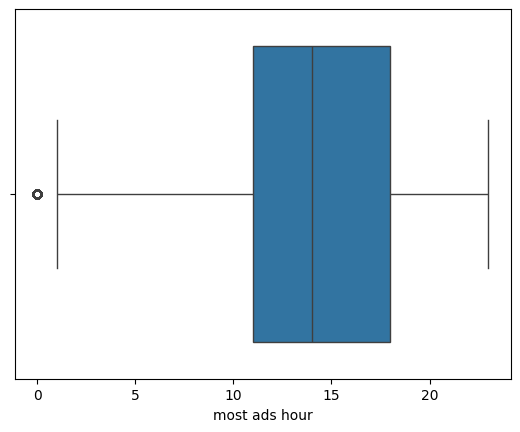

In [7]:
sns.boxplot(x = df['most ads hour'])

<Axes: xlabel='total ads'>

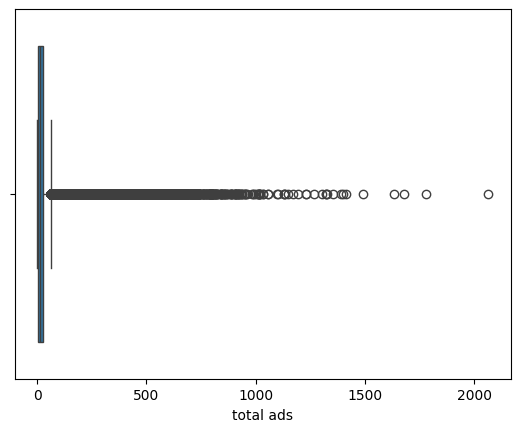

In [8]:
sns.boxplot(x = df['total ads'])

<Axes: xlabel='most ads hour', ylabel='Count'>

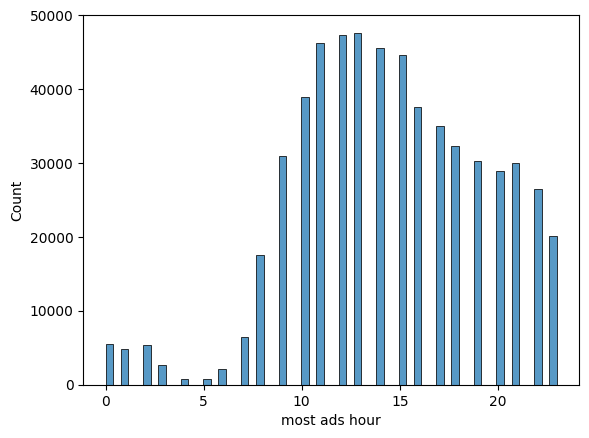

In [9]:
sns.histplot(x = df['most ads hour'], bins = 60)

<Axes: xlabel='total ads', ylabel='Count'>

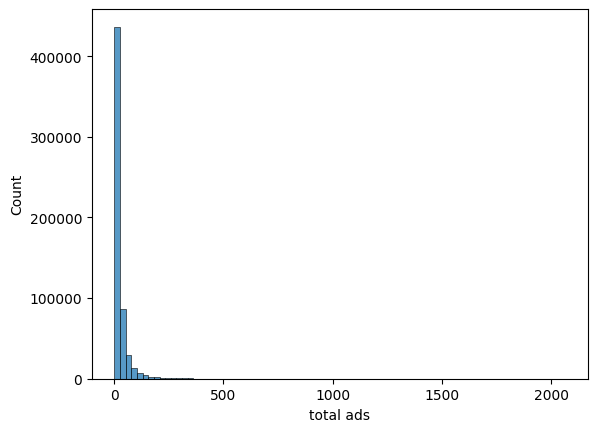

In [10]:
sns.histplot(x = df['total ads'], bins = 80)

<Axes: xlabel='converted', ylabel='count'>

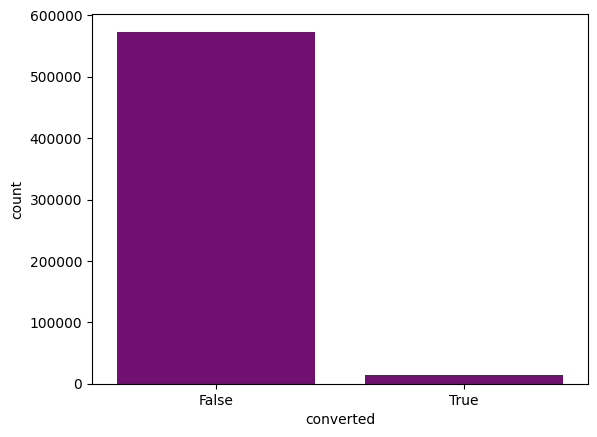

In [11]:
sns.countplot(x = df['converted'], color = 'purple')

<Axes: xlabel='most ads day', ylabel='count'>

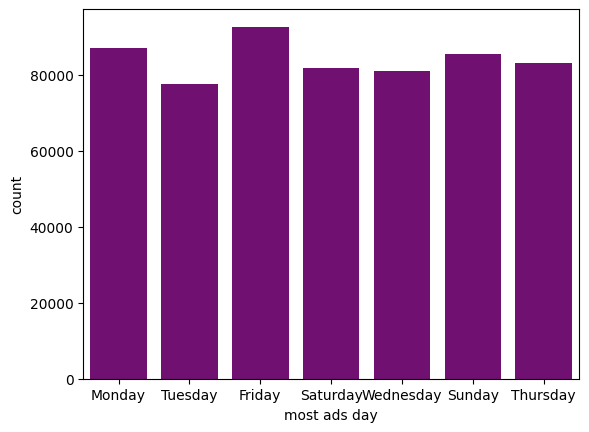

In [12]:
sns.countplot(x = df['most ads day'], color ='purple')

<Axes: xlabel='test group', ylabel='count'>

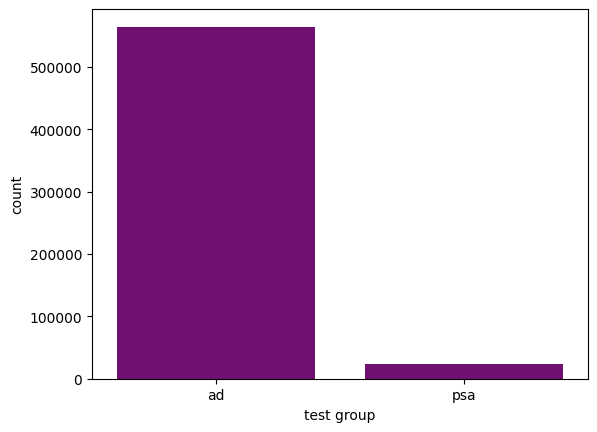

In [13]:
sns.countplot(x = df['test group'], color='purple')

####The Test Group and Converted variable is very imbalanced so I will use the balance parameter for my frequentist logisitc regression model

In [26]:
# Correlation Matrix
cor_mat = df.copy(deep = True)

del cor_mat['converted']
del cor_mat['most ads day']
del cor_mat['test group']

print(cor_mat.corr())

               total ads  most ads hour
total ads       1.000000      -0.010837
most ads hour  -0.010837       1.000000


####Numerical Variables are not strongly correlated which shows no multi-colinearity

In [15]:
# test Group & converted
tab1 = pd.crosstab(df['test group'], df['converted'])
# most ads day & converted
tab2 = pd.crosstab(df['most ads day'], df['converted'])
# most ads day & test group
tab3 = pd.crosstab(df['test group'], df['most ads day'])

# Chi-Square Test
tab1_chi2, tab1_p, tab1_dof, tab1_expected = chi2_contingency(tab1)
tab2_chi2, tab2_p, tab2_dof, tab2_expected = chi2_contingency(tab2)
tab3_chi2, tab3_p, tab3_dof, tab3_expected = chi2_contingency(tab3)

# p-values for all tables
print(f"test group & converted p-value: {round(tab1_p,3)}")
print(f"most ads day & converted: {round(tab2_p,3)}")
print(f"test group & most ads day: {round(tab3_p,3)}")

test group & converted p-value: 0.0
most ads day & converted: 0.0
test group & most ads day: 0.0


####All p-values are less than 0.05, so this means the categorical variables all seem to have some sort of relationship within each other.

In [16]:
n1 = tab1.to_numpy().sum()
n2 = tab2.to_numpy().sum()
n3 = tab3.to_numpy().sum()

# Cramer's V to find strength between variables
cram1 = np.sqrt(tab1_chi2 / (n1 * (min(tab1.shape) - 1)))
cram2 = np.sqrt(tab2_chi2 / (n2 * (min(tab2.shape) - 1)))
cram3 = np.sqrt(tab3_chi2 / (n3 * (min(tab3.shape) - 1)))

print(f"test group & converted strength: {round(cram1,2)}")
print(f"most ads day & converted strength: {round(cram2,2)}")
print(f"test group & most ads day strength: {cram3}")

test group & converted strength: 0.01
most ads day & converted strength: 0.03
test group & most ads day strength: 0.020015894535856428


###None of the categorical variables are strongly correlated which shows the categorical varibales have no multi-colinearity

###I will implement the Logistic Regression Model for Prediction

In [29]:
# Copy dataset for modeling
modelDF = df.copy(deep = True)
modelDF.head()

# Prepare Features

# 1 for the weekdays & 0 for the weekend
modelDF['most ads day'] = modelDF['most ads day'].map({'Monday': 1, 'Tuesday': 1, 'Wednesday': 1, 'Thursday': 1, 'Friday': 1, 'Saturday': 0, 'Sunday': 0})

# 0 if a psa was seen & 1 for an advertisment
modelDF['group'] = modelDF['test group'].map({'psa': 0, 'ad': 1})

# 1 if someone purchased the product & 0 if someone did not buy it
modelDF['purchase'] = modelDF['converted'].map({False: 0, True: 1})

# 0 means ad or psa was seen in the AM
# 1 means ad or psa was seen in the PM
mapping = {h: 0 if h < 12 else 1 for h in range(24)}

modelDF['ads hour'] = modelDF['most ads hour'].map(mapping)


modelDF = modelDF.drop(['test group', 'converted', 'most ads hour'], axis=1)

###Variables: <b><i>most ads day, test group, and converted</i></b> were mapped to binary indicactors, e.g. 1 & 0 before modelling.





In [30]:
# Libraries for pipelining and scaling
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

# Make a pipeline to log and scale total ads feature for modelling
pipeline = Pipeline([
    ('log',   FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])

modelDF['total ads'] = pipeline.fit_transform(modelDF[['total ads']])



print(modelDF.isnull().sum())

total ads       0
most ads day    0
group           0
purchase        0
ads hour        0
dtype: int64


##<b><u>Implementing Logistic Regression</u></b>

###<u>Model Paramters</u>:
<ul>
<li><b>penalty:</b> L2 is used to prevent overfitting by shrinking coefficients </li>

<li><b>solver:</b> lbfgs is the default parameter
</li>

<li><b>class_weight: </b>balanced is used to account for the imbalance of
the outcome variable, <i>purchase</i>
</li>

<li><b>random state: </b>Used to make outcomes reproducible
</li>

<li><b>max_iter: </b>Uses 1,000 attempts to find best coefficients
</li>
</ul>

In [20]:
# Define features and target
freq_X = modelDF.drop(['purchase'], axis=1)
freq_y = modelDF['purchase']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    freq_X, freq_y,
    test_size=0.2,
    random_state=42,
    stratify=freq_y  # preserves purchase imbalance ratio in both splits
)

# Define and fit the model
model = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    class_weight='balanced',
    random_state=42,
    max_iter=1000
)

model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [21]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

        feature  coefficient  odds_ratio
0     total ads     1.561533    4.766123
3      ads hour     0.351120    1.420658
2         group     0.287307    1.332834
1  most ads day     0.201840    1.223653

AUC Score: 0.858

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.77      0.87    114652
           1       0.08      0.82      0.15      2969

    accuracy                           0.77    117621
   macro avg       0.54      0.79      0.51    117621
weighted avg       0.97      0.77      0.85    117621



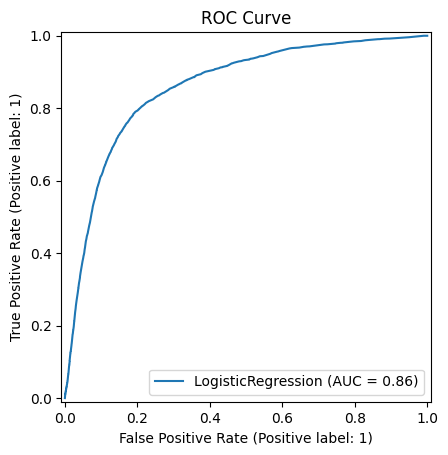

In [22]:
# Preditor coefficents
odds_ratios = pd.DataFrame({
    'feature': freq_X.columns,
    'coefficient': model.coef_[0],
    'odds_ratio': np.exp(model.coef_[0])
}).sort_values('odds_ratio', ascending=False)

print(odds_ratios)


# AUC & other metrics
print("\nAUC Score:", round(roc_auc_score(y_test, y_prob),3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ROC Curve
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title('ROC Curve')
plt.show()

###The model has a <b>AUC</b> of 85.8%, meaning if you picked one buyer and a non-buyer at random, it can sepreate buyers and non-buyers 85.8% of the time

###<b>Precision</b> and <b>Recall</b> is 8% and 82% respectivley, which means of all the people the model predicted to purchase the product only 8% did, and the model correctly identified the people who purchased the prodcut was 82% of the time

###A 1% increase in <b><i>total ads</i></b> seen is associated with  4.77 times higher odds of purchasing the product.

##<b><u>Conclusion</b></u>

###The model can distinguish buyers and non-buyers 85.5% of the time. Of all actual purchasers, the model correctly identified 82%, though only 8% of predicted purchasers actually bought the product, the model tends to over-predict purchases, catching most real buyers but also incorrectly predicting many non-buyers as purchasers. The strongest driver of purchase was total ads seen — a 1% increase in ads seen was associated with 4.77 times higher odds of purchasing, indicating that ad exposure is the primary predictor of conversion.